# 不動産投資シミュレーター v2（CF + PL + NAV + Drawdown 統合分析）

## 目的
単一物件の長期保有における **キャッシュフロー・PL・税引後NAV・Drawdown** を
年次ベースで統合的に分析するためのシミュレーターです。

### v1 → v2 の主な追加テーマ
1. **キャッシュフロー項目別の累積分析** — 項目別累積 CF + Break-even Year + Peak Negative CF
2. **Operating P/L 分析** — 会計損益 + Tax Shield
3. **年末時価評価と税引後 NAV 分析** — Market Value / Deferred Tax / Economic P/L
4. **Drawdown / Path Risk 分析** — Liquidity / NAV / Total Return の3曲線
5. **シナリオ別 Multi-Metric 比較** — IRR 以外に DSCR / ICR / Drawdown / NAV を一覧

### 構成
- **Part A**: v1 のコア関数群（日付・耐用年数・税務・収入・ローン・減価償却・シミュレーション）
- **Part B**: v2 の新規分析関数群（累積CF・Operating PL・NAV・Drawdown）
- **Part C**: 可視化・テーブル表示・シナリオ分析

### 主な前提・簡易化（v1 から継続）
- **年次ベース**（月次は将来拡張）
- 減価償却は **建物部分のみ・定額法**
- 所得税の欠損繰越は **なし**
- NAV / unrealized gain / deferred tax は **モデル上の推定値**であり、厳密な税務計算ではない
- CAPEX の税務上の資本化は **v2 では簡易化**（全額費用処理）
  - 実際には大規模修繕は資産計上 → 追加償却が正しいが、v2 では非対応
  - adjusted_total_tax_basis に capex 累計は含めていない（保守的な見積り）
- Economic P/L は **投資分析用の概念** であり、GAAP/IFRS の会計 PL とは異なる

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from copy import deepcopy
from datetime import date, timedelta

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

try:
    import matplotlib
    matplotlib.rcParams["font.family"] = "sans-serif"
    matplotlib.rcParams["font.sans-serif"] = [
        "IPAexGothic", "Noto Sans CJK JP", "Yu Gothic",
        "Hiragino Sans", "DejaVu Sans",
    ]
    matplotlib.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
# Part A: v1 コア関数群

以下のセクションは v1 から継承した関数群です。
日付ヘルパー、法定耐用年数、中古耐用年数、税務関数、enrich_params、
パラメータ定義、収入・ローン・減価償却スケジュール、統合シミュレーション関数を含みます。

## 日付・建物属性の前処理ヘルパー関数

In [2]:
def parse_year_month(ym_str):
    """'YYYY-MM' 形式の文字列を (year, month) タプルに変換する。"""
    parts = ym_str.strip().split("-")
    if len(parts) != 2:
        raise ValueError(f"Expected 'YYYY-MM' format, got: {ym_str!r}")
    return int(parts[0]), int(parts[1])


def parse_date(date_str):
    """'YYYY-MM-DD' 形式の文字列を datetime.date に変換する。"""
    parts = date_str.strip().split("-")
    if len(parts) != 3:
        raise ValueError(f"Expected 'YYYY-MM-DD' format, got: {date_str!r}")
    return date(int(parts[0]), int(parts[1]), int(parts[2]))


def months_between(start_year, start_month, end_year, end_month):
    """2 つの年月間の月数を計算する。"""
    return (end_year - start_year) * 12 + (end_month - start_month)


def compute_building_age_at_purchase(transaction_date_str, building_completion_ym_str):
    """取引日時点の建物築年数（年・簡易版）を計算する。"""
    tx = parse_date(transaction_date_str)
    comp_y, comp_m = parse_year_month(building_completion_ym_str)
    total_months = months_between(comp_y, comp_m, tx.year, tx.month)
    if total_months < 0:
        raise ValueError("building_completion_ym is after transaction_date")
    return total_months // 12

print(f"築年数テスト: 2010-06 → 2026-04 = {compute_building_age_at_purchase('2026-04-01', '2010-06')} 年")

築年数テスト: 2010-06 → 2026-04 = 15 年


## 法定耐用年数テーブル

| 構造 | 用途 | 耐用年数 |
|------|------|----------|
| wood | residential | 22 年 |
| wood_mortar | residential | 20 年 |
| rc | residential | 47 年 |
| src | residential | 47 年 |
| steel (> 4mm) | residential | 34 年 |
| steel (3-4mm) | residential | 27 年 |
| steel (≤ 3mm) | residential | 19 年 |

In [3]:
STATUTORY_USEFUL_LIFE = {
    ("wood",        "residential"): 22,
    ("wood_mortar", "residential"): 20,
    ("rc",          "residential"): 47,
    ("src",         "residential"): 47,
    ("steel",       "residential"): None,
}

STEEL_LIFE_BY_THICKNESS = {
    "residential": [
        (lambda mm: mm > 4,        34),
        (lambda mm: 3 < mm <= 4,   27),
        (lambda mm: mm <= 3,       19),
    ]
}


def lookup_statutory_useful_life(structure, usage, steel_thickness_mm=None):
    """建物構造・用途から法定耐用年数を取得する。"""
    key = (structure, usage)
    if key not in STATUTORY_USEFUL_LIFE:
        raise ValueError(f"Unsupported structure/usage: {key}")
    life = STATUTORY_USEFUL_LIFE[key]
    if life is not None:
        return life
    if structure == "steel":
        if steel_thickness_mm is None:
            raise ValueError("steel_thickness_mm required for steel")
        for cond_fn, years in STEEL_LIFE_BY_THICKNESS.get(usage, []):
            if cond_fn(steel_thickness_mm):
                return years
        raise ValueError(f"No matching rule for steel {steel_thickness_mm}mm")
    raise ValueError(f"Cannot determine useful life for {key}")

print(f"rc residential: {lookup_statutory_useful_life('rc', 'residential')} 年")

rc residential: 47 年


## 中古資産の耐用年数（簡便法）

- 全部経過: $\lfloor \text{stat\_life} \times 0.2 \rfloor$
- 一部経過: $\lfloor (\text{stat\_life} - \text{elapsed}) + \text{elapsed} \times 0.2 \rfloor$
- 最低 2 年

In [4]:
def compute_used_asset_useful_life(stat_life, elapsed_years):
    """中古資産の簡便法による耐用年数を計算する。最低 2 年。"""
    if elapsed_years < 0:
        raise ValueError(f"elapsed_years must be >= 0, got {elapsed_years}")
    if elapsed_years >= stat_life:
        estimated = math.floor(stat_life * 0.2)
    else:
        estimated = math.floor((stat_life - elapsed_years) + elapsed_years * 0.2)
    return max(estimated, 2)

print(f"RC(47年) 築16年: {compute_used_asset_useful_life(47, 16)} 年")
print(f"RC(47年) 築50年: {compute_used_asset_useful_life(47, 50)} 年")

RC(47年) 築16年: 34 年
RC(47年) 築50年: 9 年


## 税務関数

### 保有中課税
| 区分 | 計算方法 |
|------|----------|
| individual | `Taxable Income × (income_tax_rate_national + resident_tax_rate)` |
| corporate | `Taxable Income × corporate_effective_tax_rate` |

### 売却時課税（個人）
| 区分 | 所有期間 | 所得税 | 住民税 | 復興特別所得税 |
|------|----------|--------|--------|----------------|
| 短期譲渡 | 5年以下 | 30% | 9% | 所得税×2.1% |
| 長期譲渡 | 5年超 | 15% | 5% | 所得税×2.1% |

In [5]:
def determine_individual_sale_term(acquisition_date_str, sale_date_str):
    """個人の譲渡所得が長期/短期かを判定する（簡易版）。"""
    acq = parse_date(acquisition_date_str)
    sale = parse_date(sale_date_str)
    jan1 = date(sale.year, 1, 1)
    if (jan1 - acq).days > 5 * 365:
        return "long_term"
    return "short_term"


def determine_individual_capital_gains_tax_rate(
    acquisition_date_str, sale_date_str,
    resident_tax_rate=0.05, reconstruction_special_tax_rate=0.021,
):
    """個人の譲渡所得税率を返す。"""
    term = determine_individual_sale_term(acquisition_date_str, sale_date_str)
    if term == "long_term":
        income_tax, res_tax = 0.15, resident_tax_rate
    else:
        income_tax, res_tax = 0.30, 0.09
    reconstruction = income_tax * reconstruction_special_tax_rate
    return {
        "sale_term_type": term,
        "income_tax_rate": income_tax,
        "resident_tax_rate": res_tax,
        "reconstruction_surtax_rate": reconstruction,
        "total_rate": income_tax + res_tax + reconstruction,
    }


def compute_holding_tax(taxable_income, params):
    """保有中の所得税を計算する。"""
    if taxable_income <= 0:
        return 0.0
    if params.get("ownership_type", "individual") == "corporate":
        return taxable_income * params["corporate_effective_tax_rate"]
    return taxable_income * (params["income_tax_rate_national"] + params["resident_tax_rate"])


def compute_sale_tax(taxable_gain, params):
    """売却時の譲渡税を計算する。"""
    if taxable_gain <= 0:
        return 0.0
    if params.get("ownership_type", "individual") == "corporate":
        return taxable_gain * params["corporate_effective_tax_rate"]
    return taxable_gain * params.get("sale_tax_info", {}).get("total_rate", 0.2)


_info = determine_individual_capital_gains_tax_rate("2026-04-01", "2036-04-01")
print(f"10年保有 → {_info['sale_term_type']}, 税率: {_info['total_rate']:.4%}")

10年保有 → long_term, 税率: 20.3150%


## パラメータ自動補完 (`enrich_params`)

In [6]:
def enrich_params(params):
    """入力パラメータを元に、築年数・耐用年数・税率等を自動計算して補完する。

    副作用なし（コピーを返す）。
    """
    p = deepcopy(params)

    p["building_age_years_at_purchase"] = compute_building_age_at_purchase(
        p["transaction_date"], p["building_completion_ym"])
    p["statutory_useful_life_years"] = lookup_statutory_useful_life(
        p["building_structure"], p["building_usage"], p.get("steel_thickness_mm"))
    p["building_useful_life_years"] = compute_used_asset_useful_life(
        p["statutory_useful_life_years"], p["building_age_years_at_purchase"])
    p["land_growth_rate"] = p["inflation_rate"] + p["land_real_appreciation_spread"]
    p["building_growth_rate"] = p["inflation_rate"] + p["building_real_appreciation_spread"]

    tx = parse_date(p["transaction_date"])
    sale_year = tx.year + p["hold_period_years"]
    try:
        p["inferred_sale_date"] = date(sale_year, tx.month, tx.day).isoformat()
    except ValueError:
        p["inferred_sale_date"] = date(sale_year, tx.month, tx.day - 1).isoformat()

    ownership = p.get("ownership_type", "individual")
    if ownership == "individual":
        sale_tax_info = determine_individual_capital_gains_tax_rate(
            p["transaction_date"], p["inferred_sale_date"],
            p.get("resident_tax_rate", 0.05), p.get("reconstruction_special_tax_rate", 0.021))
        p["sale_tax_info"] = sale_tax_info
        p["sale_term_type"] = sale_tax_info["sale_term_type"]
        p["holding_effective_tax_rate"] = p["income_tax_rate_national"] + p["resident_tax_rate"]
    else:
        p["sale_tax_info"] = {"total_rate": p["corporate_effective_tax_rate"]}
        p["sale_term_type"] = "corporate"
        p["holding_effective_tax_rate"] = p["corporate_effective_tax_rate"]

    p["income_tax_rate"] = p["holding_effective_tax_rate"]
    return p

print("enrich_params 定義完了")

enrich_params 定義完了


## 基本前提条件の入力

サンプルケース: RC 築15年、個人、10年保有、1億円

In [7]:
params = {
    "purchase_price":          100_000_000,
    "land_value":               35_000_000,
    "building_value":           65_000_000,
    "acquisition_cost_rate":          0.07,
    "initial_capex":             2_000_000,
    "hold_period_years":                10,
    "building_structure":             "rc",
    "building_usage":       "residential",
    "building_completion_ym":    "2010-06",
    "steel_thickness_mm":           None,
    "transaction_date":      "2026-04-01",
    "initial_gross_rent":        8_400_000,
    "vacancy_rate":                  0.05,
    "rent_growth_rate":             0.005,
    "other_income":                200_000,
    "other_income_growth_rate":      0.00,
    "initial_operating_expenses": 1_000_000,
    "opex_growth_rate":               0.01,
    "property_tax":                900_000,
    "property_tax_growth_rate":      0.005,
    "repair_cost":                 300_000,
    "repair_growth_rate":             0.02,
    "capex_schedule":          {5: 1_500_000},
    "ltv":                           0.80,
    "interest_rate":                 0.02,
    "loan_term_years":                 30,
    "amortization_type":   "equal_payment",
    "io_years":                         0,
    "depreciation_method":  "straight_line",
    "inflation_rate":                0.02,
    "land_real_appreciation_spread":  0.005,
    "building_real_appreciation_spread": -0.01,
    "exit_cap_rate":                 0.05,
    "closing_cost_on_sale_rate":    0.035,
    "exit_price_method":       "cap_rate",
    "ownership_type":        "individual",
    "income_tax_rate_national":      0.20,
    "resident_tax_rate":             0.05,
    "reconstruction_special_tax_rate": 0.021,
    "corporate_effective_tax_rate":   0.30,
}

params = enrich_params(params)

print("パラメータ設定完了 (enriched)")
print(f"  物件価格:       {params['purchase_price']:>15,.0f} 円")
print(f"  築年数:         {params['building_age_years_at_purchase']:>15} 年")
print(f"  中古耐用年数:   {params['building_useful_life_years']:>15} 年")
print(f"  所有形態:       {params['ownership_type']:>15}")
print(f"  譲渡区分:       {params['sale_term_type']:>15}")

パラメータ設定完了 (enriched)
  物件価格:           100,000,000 円
  築年数:                      15 年
  中古耐用年数:                35 年
  所有形態:            individual
  譲渡区分:             long_term


## 年次収入・NOI 計算

$$\text{NOI}_t = \text{EGI}_t - \text{OpEx}_t - \text{Property Tax}_t - \text{Repair}_t$$

> Capex は NOI に含めず、BTCF で別途控除。

In [8]:
def build_revenue_schedule(params):
    """年次収入・NOI スケジュールを構築する。"""
    hold = params["hold_period_years"]
    records = []
    for y in range(1, hold + 1):
        t = y - 1
        gross_rent = params["initial_gross_rent"] * (1 + params["rent_growth_rate"]) ** t
        vacancy_loss = gross_rent * params["vacancy_rate"]
        other_inc = params["other_income"] * (1 + params["other_income_growth_rate"]) ** t
        egi = gross_rent - vacancy_loss + other_inc
        opex = params["initial_operating_expenses"] * (1 + params["opex_growth_rate"]) ** t
        ptax = params["property_tax"] * (1 + params["property_tax_growth_rate"]) ** t
        repair = params["repair_cost"] * (1 + params["repair_growth_rate"]) ** t
        capex = params.get("capex_schedule", {}).get(y, 0)
        noi = egi - opex - ptax - repair
        records.append({"year": y, "gross_rent": gross_rent, "vacancy_loss": vacancy_loss,
                        "other_income": other_inc, "egi": egi, "operating_expenses": opex,
                        "property_tax": ptax, "repair_cost": repair, "capex": capex, "noi": noi})
    return pd.DataFrame(records)

print(f"Year 1 NOI: {build_revenue_schedule(params).loc[0, 'noi']:,.0f}")

Year 1 NOI: 5,980,000


## 借入返済スケジュール

In [9]:
def _calc_pmt(principal, rate, periods):
    """元利均等返済の年間返済額を計算する。"""
    if rate == 0:
        return principal / periods
    return principal * rate * (1 + rate) ** periods / ((1 + rate) ** periods - 1)


def build_loan_schedule(params):
    """借入返済スケジュールを構築する。"""
    loan_amount = params["purchase_price"] * params["ltv"]
    rate = params["interest_rate"]
    n = params["loan_term_years"]
    hold = params["hold_period_years"]
    amort_type = params.get("amortization_type", "equal_payment")
    io_years = params.get("io_years", 0)
    records, balance, annual_payment = [], loan_amount, None

    for y in range(1, hold + 1):
        if balance <= 0 or y > n:
            records.append({"year": y, "interest": 0.0, "principal": 0.0,
                            "debt_service": 0.0, "loan_balance_end": 0.0})
            continue
        interest = balance * rate
        if amort_type == "interest_only_then_amortizing" and y <= io_years:
            principal_paid, ds = 0.0, interest
        else:
            if annual_payment is None:
                if amort_type == "equal_payment":
                    annual_payment = _calc_pmt(loan_amount, rate, n)
                else:
                    annual_payment = _calc_pmt(balance, rate, n - io_years)
            principal_paid = annual_payment - interest
            ds = annual_payment
        balance = max(balance - principal_paid, 0.0)
        records.append({"year": y, "interest": interest, "principal": principal_paid,
                        "debt_service": ds, "loan_balance_end": balance})
    return pd.DataFrame(records)

_l = build_loan_schedule(params)
print(f"Year 1 Debt Service: {_l.loc[0, 'debt_service']:,.0f}")

Year 1 Debt Service: 3,571,994


## 減価償却（定額法・建物部分のみ）

In [10]:
def build_depreciation_schedule(params):
    """建物の定額法減価償却スケジュールを構築する。"""
    bv = params["building_value"]
    life = params["building_useful_life_years"]
    hold = params["hold_period_years"]
    annual_dep = bv / life
    records = [{"year": y, "depreciation": annual_dep if y <= life else 0.0}
               for y in range(1, hold + 1)]
    return pd.DataFrame(records)

print(f"年間償却額: {build_depreciation_schedule(params).loc[0, 'depreciation']:,.0f}")

年間償却額: 1,857,143


## 統合シミュレーション関数

v1 の `run_simulation` を維持。売却価格は `exit_price_method` で切替。

In [11]:
def run_simulation(params):
    """統合シミュレーションを実行する。

    Returns:
        df (pd.DataFrame): 年次キャッシュフローテーブル
        summary (dict): 取得・売却に関する要約情報
    """
    rev_df = build_revenue_schedule(params)
    loan_df = build_loan_schedule(params)
    dep_df = build_depreciation_schedule(params)

    df = rev_df.merge(loan_df, on="year").merge(dep_df, on="year")
    df["btcf"] = df["noi"] - df["debt_service"] - df["capex"]
    df["taxable_income"] = df["noi"] - df["interest"] - df["depreciation"]
    df["tax"] = df["taxable_income"].apply(lambda ti: compute_holding_tax(ti, params))
    df["atcf"] = df["btcf"] - df["tax"]

    total_acquisition = params["purchase_price"] * (1 + params["acquisition_cost_rate"]) + params["initial_capex"]
    loan_amount = params["purchase_price"] * params["ltv"]
    equity_invested = total_acquisition - loan_amount

    hold = params["hold_period_years"]
    terminal_noi = df.loc[df["year"] == hold, "noi"].values[0]

    sale_price_cap = terminal_noi / params["exit_cap_rate"] if params["exit_cap_rate"] > 0 else 0
    land_sv = params["land_value"] * (1 + params["land_growth_rate"]) ** hold
    bldg_sv = params["building_value"] * (1 + params["building_growth_rate"]) ** hold
    sale_price_comp = land_sv + bldg_sv

    method = params.get("exit_price_method", "cap_rate")
    sale_price = sale_price_comp if method == "component_growth" else sale_price_cap

    selling_costs = sale_price * params["closing_cost_on_sale_rate"]
    net_sale_price = sale_price - selling_costs
    loan_balance_at_sale = df.loc[df["year"] == hold, "loan_balance_end"].values[0]
    bt_sale_proceeds = net_sale_price - loan_balance_at_sale

    accumulated_dep = df["depreciation"].sum()
    total_capex_spent = df["capex"].sum()
    cost_basis = (params["purchase_price"] + params["purchase_price"] * params["acquisition_cost_rate"]
                  + params["initial_capex"] + total_capex_spent)
    adjusted_basis = cost_basis - accumulated_dep
    taxable_gain = net_sale_price - adjusted_basis
    capital_gains_tax = compute_sale_tax(taxable_gain, params)
    net_sale_proceeds = bt_sale_proceeds - capital_gains_tax

    df["sale_proceeds_net"] = 0.0
    df.loc[df["year"] == hold, "sale_proceeds_net"] = net_sale_proceeds
    df["total_equity_cf"] = df["atcf"] + df["sale_proceeds_net"]
    df["cumulative_atcf"] = df["atcf"].cumsum()
    df["cumulative_equity_cf"] = df["total_equity_cf"].cumsum()
    df["cumulative_equity_cf_with_initial"] = df["cumulative_equity_cf"] - equity_invested

    sale_tax_info = params.get("sale_tax_info", {})
    summary = {
        "total_acquisition_cost": total_acquisition,
        "loan_amount": loan_amount,
        "equity_invested": equity_invested,
        "sale_price_cap_rate": sale_price_cap,
        "sale_price_component_growth": sale_price_comp,
        "sale_price_selected": sale_price,
        "exit_price_method": method,
        "selling_costs": selling_costs,
        "net_sale_price": net_sale_price,
        "loan_balance_at_sale": loan_balance_at_sale,
        "bt_sale_proceeds": bt_sale_proceeds,
        "cost_basis": cost_basis,
        "accumulated_depreciation": accumulated_dep,
        "adjusted_basis": adjusted_basis,
        "taxable_gain": taxable_gain,
        "capital_gains_tax": capital_gains_tax,
        "sale_tax_rate_applied": sale_tax_info.get("total_rate", None),
        "net_sale_proceeds": net_sale_proceeds,
        "terminal_noi": terminal_noi,
        "building_age_years_at_purchase": params.get("building_age_years_at_purchase"),
        "statutory_useful_life_years": params.get("statutory_useful_life_years"),
        "building_useful_life_years": params.get("building_useful_life_years"),
        "land_growth_rate": params.get("land_growth_rate"),
        "building_growth_rate": params.get("building_growth_rate"),
        "sale_term_type": params.get("sale_term_type"),
    }
    return df, summary

print("run_simulation 定義完了")

run_simulation 定義完了


## 投資指標の計算（v2 拡張）

v1 指標に加え、以下を追加:
- **ICR** (Interest Coverage Ratio) = NOI / Interest
- **Break-even Year (cash)**: cumulative_equity_cf_with_initial が初めて 0 超の年
- **Peak Negative Cumulative CF**: cumulative_equity_cf_with_initial の最小値

In [12]:
def _compute_irr(cashflows, tol=1e-10, max_iter=1000):
    """IRR を二分法で計算する。"""
    def npv(rate):
        return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))
    low, high = -0.50, 2.00
    npv_low, npv_high = npv(low), npv(high)
    if npv_low * npv_high > 0:
        return None
    for _ in range(max_iter):
        mid = (low + high) / 2.0
        npv_mid = npv(mid)
        if abs(npv_mid) < tol or (high - low) / 2 < tol:
            return mid
        if npv_low * npv_mid < 0:
            high, npv_high = mid, npv_mid
        else:
            low, npv_low = mid, npv_mid
    return (low + high) / 2.0


def compute_metrics(params, df, summary):
    """主要投資指標を計算する（v2 拡張: ICR, break-even, peak negative CF）。

    Returns:
        metrics (dict), df (pd.DataFrame)
    """
    equity = summary["equity_invested"]
    hold = params["hold_period_years"]
    year1_noi = df.loc[df["year"] == 1, "noi"].values[0]
    cap_rate = year1_noi / params["purchase_price"]
    df["cash_on_cash"] = df["btcf"] / equity
    df["dscr"] = df.apply(
        lambda r: r["noi"] / r["debt_service"] if r["debt_service"] > 0 else np.inf, axis=1)
    df["icr"] = df.apply(
        lambda r: r["noi"] / r["interest"] if r["interest"] > 0 else np.inf, axis=1)

    equity_cfs = [-equity] + df["total_equity_cf"].tolist()
    equity_irr = _compute_irr(equity_cfs)

    project_cfs = [-summary["total_acquisition_cost"]]
    for _, row in df.iterrows():
        cf = row["noi"] - row["capex"]
        if row["year"] == hold:
            cf += summary["net_sale_price"]
        project_cfs.append(cf)
    project_irr = _compute_irr(project_cfs)

    total_received = df["total_equity_cf"].sum()
    equity_multiple = total_received / equity

    # Break-even year (cash)
    cum_with_init = df["cumulative_equity_cf_with_initial"]
    be_rows = df.loc[cum_with_init > 0, "year"]
    break_even_year_cash = int(be_rows.iloc[0]) if len(be_rows) > 0 else None

    peak_negative_cf = cum_with_init.min()

    metrics = {
        "cap_rate": cap_rate,
        "avg_cash_on_cash": df["cash_on_cash"].mean(),
        "equity_irr": equity_irr,
        "project_irr": project_irr,
        "equity_multiple": equity_multiple,
        "min_dscr": df["dscr"].replace(np.inf, np.nan).min(),
        "avg_dscr": df["dscr"].replace(np.inf, np.nan).mean(),
        "min_icr": df["icr"].replace(np.inf, np.nan).min(),
        "avg_icr": df["icr"].replace(np.inf, np.nan).mean(),
        "break_even_year_cash": break_even_year_cash,
        "peak_negative_cf": peak_negative_cf,
    }
    return metrics, df

print("compute_metrics 定義完了 (v2 拡張)")

compute_metrics 定義完了 (v2 拡張)


---
# Part B: v2 新規分析関数群

以下のセクションは v2 で新たに追加した分析関数です。

## 1. キャッシュフロー項目別累積分析

各年の個別 CF 項目を累積し、以下の派生指標も計算します。

- **break_even_year_cash**: cumulative_equity_cf_with_initial が初めて 0 超の年
- **peak_negative_cumulative_cf**: cumulative_equity_cf_with_initial の最小値
- **cash_recovery_ratio**: cum_total_equity_cf / equity_invested

In [13]:
def add_cumulative_cashflow_columns(df, params):
    """年次 DataFrame に累積 CF 列と派生指標を追加する。

    Args:
        df: run_simulation の返り値 DataFrame
        params: enriched params

    Returns:
        df (pd.DataFrame): 累積列を追加済み
        cf_metrics (dict): break_even_year_cash, peak_negative_cumulative_cf, cash_recovery_ratio
    """
    equity = (params["purchase_price"] * (1 + params["acquisition_cost_rate"])
              + params["initial_capex"]) - params["purchase_price"] * params["ltv"]

    cum_cols = [
        "gross_rent", "vacancy_loss", "egi", "operating_expenses",
        "property_tax", "repair_cost", "noi", "capex",
        "interest", "principal", "debt_service", "depreciation",
        "tax", "btcf", "atcf", "sale_proceeds_net", "total_equity_cf",
    ]
    for col in cum_cols:
        df[f"cum_{col}"] = df[col].cumsum()

    # cumulative_equity_cf_with_initial は既に run_simulation で作成済み
    # cash_recovery_ratio
    df["cash_recovery_ratio"] = df["cum_total_equity_cf"] / equity

    cum_init = df["cumulative_equity_cf_with_initial"]
    be_rows = df.loc[cum_init > 0, "year"]
    break_even = int(be_rows.iloc[0]) if len(be_rows) > 0 else None
    peak_neg = cum_init.min()

    cf_metrics = {
        "break_even_year_cash": break_even,
        "peak_negative_cumulative_cf": peak_neg,
        "cash_recovery_ratio_final": df["cash_recovery_ratio"].iloc[-1],
    }
    return df, cf_metrics

print("add_cumulative_cashflow_columns 定義完了")

add_cumulative_cashflow_columns 定義完了


## 2. Operating P/L 分析

保有中の事業損益を分析します（元本返済は含めない）。

- `operating_profit_before_dep` = EGI - OpEx - Property Tax - Repair
- `accounting_pre_tax_income` = operating_profit_before_dep - Depreciation - Interest
- `accounting_after_tax_income` = pre_tax_income - holding_tax

### Tax Shield
- `depreciation_tax_shield` = Depreciation × applicable_holding_tax_rate
- `interest_tax_shield` = Interest × applicable_holding_tax_rate

> **注意**: これは会計的な PL であり、キャッシュフロー (BTCF/ATCF) とは異なります。
> 元本返済・Capex は PL に含まれません。

In [14]:
def build_operating_pl_table(df, params):
    """年次の Operating P/L テーブルを構築する。

    Args:
        df: run_simulation の返り値 DataFrame
        params: enriched params

    Returns:
        pl_df (pd.DataFrame): Operating P/L テーブル
    """
    tax_rate = params["holding_effective_tax_rate"]

    pl = pd.DataFrame()
    pl["year"] = df["year"]
    pl["rental_revenue"] = df["gross_rent"] - df["vacancy_loss"]
    pl["other_income"] = df["other_income"]
    pl["effective_gross_income"] = df["egi"]
    pl["operating_expenses"] = df["operating_expenses"]
    pl["property_tax"] = df["property_tax"]
    pl["repair_cost"] = df["repair_cost"]
    pl["operating_profit_before_dep"] = (
        pl["effective_gross_income"] - pl["operating_expenses"]
        - pl["property_tax"] - pl["repair_cost"]
    )
    pl["depreciation"] = df["depreciation"]
    pl["interest"] = df["interest"]
    pl["accounting_pre_tax_income"] = (
        pl["operating_profit_before_dep"] - pl["depreciation"] - pl["interest"]
    )
    pl["holding_tax"] = df["tax"]
    pl["accounting_after_tax_income"] = pl["accounting_pre_tax_income"] - pl["holding_tax"]

    # Tax shields
    pl["depreciation_tax_shield"] = pl["depreciation"] * tax_rate
    pl["interest_tax_shield"] = pl["interest"] * tax_rate

    return pl

print("build_operating_pl_table 定義完了")

build_operating_pl_table 定義完了


## 3. Market Value / NAV / Deferred Tax / Economic P/L 分析

各年末における「いま売ったらどの程度の税引後純資産価値があるか」を分析します。

> **重要**: ここで計算する NAV / unrealized gain / deferred tax は
> **投資分析用のモデル推定値** であり、実際の税務申告や GAAP/IFRS 会計とは異なります。

### estimated_market_value
- **cap_rate モード**: `noi_t / exit_cap_rate`（当年 NOI ベース）
- **component_growth モード**: 土地・建物を別々に成長

> cap_rate モードでは当年 NOI を使用（forward NOI ではない）。
> これは「現在の収益力での時価」という保守的な推定です。

### Economic P/L の定義
$$
\text{economic\_profit\_after\_tax} = \text{atcf} + \Delta\text{nav\_after\_tax}
$$
- ATCF: 当年の税引後手取りキャッシュフロー（分配に相当）
- Δ NAV after tax: 年末 NAV の前年比変動

> これは「現金回収 + 資産価値変動」を合算した **トータルリターンベースの利益** です。
> 会計上の `accounting_after_tax_income` とは別物です。

### CAPEX の税務上の扱い（v2 簡易化）
- v2 では Capex を税務上全額費用処理として扱い、adjusted_total_tax_basis には累計しません
- 実際には大規模修繕は資産計上 → 追加償却が正しい処理です（v3 対応予定）

In [15]:
def _compute_deferred_sale_tax_at_year(year, params, cum_dep, estimated_mv, selling_cost):
    """年末時点で売却したと仮定した場合の概算譲渡税を計算する。

    Args:
        year: 保有年数
        params: enriched params
        cum_dep: 累計減価償却
        estimated_mv: 推定時価
        selling_cost: 推定売却諸費用

    Returns:
        float: deferred_sale_tax (非負)
    """
    # adjusted tax basis (簡易版)
    adj_building_bv = max(params["building_value"] - cum_dep, 0)
    adj_tax_basis = params["land_value"] + adj_building_bv

    net_mv = estimated_mv - selling_cost
    unrealized_gain = net_mv - adj_tax_basis

    if unrealized_gain <= 0:
        return 0.0

    ownership = params.get("ownership_type", "individual")
    if ownership == "corporate":
        return unrealized_gain * params["corporate_effective_tax_rate"]

    # individual: 年末時点で売却したと仮定して long/short 判定
    tx = parse_date(params["transaction_date"])
    try:
        hypo_sale = date(tx.year + year, tx.month, tx.day)
    except ValueError:
        hypo_sale = date(tx.year + year, tx.month, tx.day - 1)

    tax_info = determine_individual_capital_gains_tax_rate(
        params["transaction_date"], hypo_sale.isoformat(),
        params.get("resident_tax_rate", 0.05),
        params.get("reconstruction_special_tax_rate", 0.021))
    return unrealized_gain * tax_info["total_rate"]


def build_nav_table(df, params):
    """年末時価評価・NAV・Economic P/L テーブルを構築する。

    Args:
        df: run_simulation の返り値 DataFrame (累積列追加済み)
        params: enriched params

    Returns:
        nav_df (pd.DataFrame): NAV テーブル
    """
    equity = (params["purchase_price"] * (1 + params["acquisition_cost_rate"])
              + params["initial_capex"]) - params["purchase_price"] * params["ltv"]
    hold = params["hold_period_years"]
    method = params.get("exit_price_method", "cap_rate")

    records = []
    for _, row in df.iterrows():
        y = int(row["year"])

        # estimated_market_value
        if method == "component_growth":
            land_v = params["land_value"] * (1 + params["land_growth_rate"]) ** y
            bldg_v = params["building_value"] * (1 + params["building_growth_rate"]) ** y
            mv = land_v + bldg_v
        else:
            noi = row["noi"]
            mv = noi / params["exit_cap_rate"] if params["exit_cap_rate"] > 0 else 0

        selling_cost = mv * params["closing_cost_on_sale_rate"]
        cum_dep = df.loc[df["year"] <= y, "depreciation"].sum()
        adj_building_bv = max(params["building_value"] - cum_dep, 0)
        adj_tax_basis = params["land_value"] + adj_building_bv

        unrealized_pre = mv - adj_tax_basis - selling_cost
        deferred_tax = _compute_deferred_sale_tax_at_year(y, params, cum_dep, mv, selling_cost)

        nav_pre = mv - row["loan_balance_end"] - selling_cost
        nav_after = nav_pre - deferred_tax
        unrealized_after = unrealized_pre - deferred_tax

        records.append({
            "year": y,
            "estimated_market_value": mv,
            "estimated_selling_cost": selling_cost,
            "adjusted_building_book_value": adj_building_bv,
            "adjusted_total_tax_basis": adj_tax_basis,
            "unrealized_gain_pre_tax": unrealized_pre,
            "deferred_sale_tax": deferred_tax,
            "nav_pre_tax": nav_pre,
            "nav_after_tax": nav_after,
            "unrealized_gain_after_tax": unrealized_after,
            "loan_balance_end": row["loan_balance_end"],
        })

    nav_df = pd.DataFrame(records)

    # nav_change_after_tax: 初年度は nav_after_tax - equity
    nav_df["nav_change_after_tax"] = nav_df["nav_after_tax"].diff()
    nav_df.loc[nav_df.index[0], "nav_change_after_tax"] = (
        nav_df.loc[nav_df.index[0], "nav_after_tax"] - equity
    )

    # economic_profit_after_tax = atcf + nav_change_after_tax
    nav_df["atcf"] = df["atcf"].values
    nav_df["economic_profit_after_tax"] = nav_df["atcf"] + nav_df["nav_change_after_tax"]

    # Break-even year (NAV): nav_after_tax >= equity
    be_nav_rows = nav_df.loc[nav_df["nav_after_tax"] >= equity, "year"]
    nav_df.attrs["break_even_year_nav"] = int(be_nav_rows.iloc[0]) if len(be_nav_rows) > 0 else None

    return nav_df

print("build_nav_table 定義完了")

build_nav_table 定義完了


## 4. Drawdown / Path Risk 分析

3 種類の equity curve に対して Drawdown を計算します。

### A. Liquidity Curve
`cumulative_equity_cf_with_initial` — 累積現金回収ベースの苦しさ

### B. NAV After Tax Curve
`nav_after_tax` — 時価評価込み・税引後純資産ベースの毀損

### C. Total Return Equity Curve
`cumulative ATCF + current NAV after tax - initial equity`
— 分配込みのトータルリターン曲線

> Drawdown は「ピークからの下落幅」として計算。
> 系列が一貫して負の場合は 0 からの下落として扱います。

In [16]:
def compute_drawdown_series(years, values):
    """年次系列に対して Drawdown を計算する。

    Args:
        years: 年のリスト/Series
        values: 値のリスト/Series

    Returns:
        pd.DataFrame: year, value, running_peak, drawdown, drawdown_pct, drawdown_duration
    """
    dd = pd.DataFrame({"year": years, "value": values}).reset_index(drop=True)
    dd["running_peak"] = dd["value"].cummax()
    # ピークが負の場合は0をピークとみなす
    dd["running_peak"] = dd["running_peak"].clip(lower=0)
    dd["drawdown"] = dd["value"] - dd["running_peak"]
    dd["drawdown_pct"] = dd.apply(
        lambda r: r["drawdown"] / r["running_peak"] if r["running_peak"] > 0 else
                  (0.0 if r["value"] >= 0 else -1.0),
        axis=1)

    # drawdown_duration: ピークから回復していない連続年数
    duration = []
    count = 0
    for _, r in dd.iterrows():
        if r["drawdown"] < -1e-6:  # tolerance
            count += 1
        else:
            count = 0
        duration.append(count)
    dd["drawdown_duration"] = duration

    return dd


def compute_path_risk_metrics(dd_df):
    """Drawdown DataFrame からリスク指標を計算する。

    Args:
        dd_df: compute_drawdown_series の返り値

    Returns:
        dict: max_drawdown_abs, max_drawdown_pct, max_drawdown_year,
              drawdown_duration_max, recovery_year_if_any,
              worst_1y_change, worst_3y_change
    """
    min_dd_idx = dd_df["drawdown"].idxmin()
    max_dd_abs = dd_df.loc[min_dd_idx, "drawdown"]
    max_dd_pct = dd_df.loc[min_dd_idx, "drawdown_pct"]
    max_dd_year = int(dd_df.loc[min_dd_idx, "year"])
    duration_max = dd_df["drawdown_duration"].max()

    # recovery: ピーク到達後の最初のピーク回復年
    peak_reached = False
    recovery_year = None
    for _, r in dd_df.iterrows():
        if r["drawdown"] < -1e-6:
            peak_reached = True
        elif peak_reached and r["drawdown"] >= -1e-6:
            recovery_year = int(r["year"])
            break

    # worst 1Y / 3Y change
    values = dd_df["value"].values
    worst_1y = np.inf
    for i in range(1, len(values)):
        change = values[i] - values[i - 1]
        worst_1y = min(worst_1y, change)
    worst_1y = worst_1y if worst_1y < np.inf else 0.0

    worst_3y = np.inf
    for i in range(3, len(values)):
        change = values[i] - values[i - 3]
        worst_3y = min(worst_3y, change)
    worst_3y = worst_3y if worst_3y < np.inf else 0.0

    return {
        "max_drawdown_abs": max_dd_abs,
        "max_drawdown_pct": max_dd_pct,
        "max_drawdown_year": max_dd_year,
        "drawdown_duration_max": duration_max,
        "recovery_year_if_any": recovery_year,
        "worst_1y_change": worst_1y,
        "worst_3y_change": worst_3y,
    }


def build_drawdown_analysis(df, nav_df, params):
    """3 種類の equity curve について Drawdown 分析を実行する。

    Args:
        df: run_simulation の返り値 DataFrame
        nav_df: build_nav_table の返り値
        params: enriched params

    Returns:
        dd_results (dict): {curve_name: {"dd_df": ..., "metrics": ...}}
    """
    equity = (params["purchase_price"] * (1 + params["acquisition_cost_rate"])
              + params["initial_capex"]) - params["purchase_price"] * params["ltv"]
    years = df["year"]

    # A. Liquidity curve
    liquidity = df["cumulative_equity_cf_with_initial"]

    # B. NAV after tax
    nav_at = nav_df["nav_after_tax"]

    # C. Total return equity curve = cum_atcf + nav_after_tax - equity
    total_return = df["cumulative_atcf"] + nav_at.values - equity

    results = {}
    for name, vals in [
        ("Liquidity", liquidity),
        ("NAV After Tax", nav_at),
        ("Total Return", total_return),
    ]:
        dd_df = compute_drawdown_series(years, vals)
        metrics = compute_path_risk_metrics(dd_df)
        results[name] = {"dd_df": dd_df, "metrics": metrics}

    return results

print("Drawdown 分析関数群 定義完了")

Drawdown 分析関数群 定義完了


## 5. シナリオ別 Multi-Metric 比較

各シナリオに対して、IRR 以外の幅広い指標を一覧で比較します。

| 指標 | 説明 |
|------|------|
| Equity IRR | エクイティ内部収益率 |
| Equity Multiple | エクイティマルチプル |
| Avg Cash-on-Cash | 平均キャッシュオンキャッシュ |
| Min DSCR | 最小 DSCR |
| Min ICR | 最小 ICR |
| Break-even Year (Cash) | 現金回収 BEP |
| Peak Neg CF | 最大累積赤字 |
| Final NAV AT | 最終年 NAV (税引後) |
| Max DD% Liquidity | 流動性曲線の最大 DD |
| Max DD% NAV | NAV 曲線の最大 DD |
| Max DD% Total Return | トータルリターン曲線の最大 DD |

In [17]:
def run_scenario(base_params, overrides):
    """パラメータを一部変更してシミュレーションを実行する。

    Returns:
        df, summary, metrics
    """
    p = deepcopy(base_params)
    p.update(overrides)
    enrich_keys = {
        "transaction_date", "building_completion_ym", "building_structure",
        "building_usage", "steel_thickness_mm", "hold_period_years",
        "inflation_rate", "land_real_appreciation_spread",
        "building_real_appreciation_spread", "ownership_type",
        "income_tax_rate_national", "resident_tax_rate",
        "reconstruction_special_tax_rate",
    }
    if any(k in overrides for k in enrich_keys):
        p = enrich_params(p)
    df_s, summary_s = run_simulation(p)
    metrics_s, df_s = compute_metrics(p, df_s, summary_s)
    return df_s, summary_s, metrics_s, p


def build_extended_scenario_summary(base_params, scenario_list):
    """シナリオリストに対して multi-metric 比較テーブルを構築する。

    Args:
        base_params: ベースパラメータ (enriched)
        scenario_list: [{"label": str, "overrides": dict}, ...]

    Returns:
        pd.DataFrame: シナリオ × 指標のサマリーテーブル
    """
    rows = []
    for sc in scenario_list:
        label = sc["label"]
        overrides = sc["overrides"]
        df_s, summary_s, metrics_s, p_s = run_scenario(base_params, overrides)
        df_s, cf_m = add_cumulative_cashflow_columns(df_s, p_s)
        nav_s = build_nav_table(df_s, p_s)
        dd_s = build_drawdown_analysis(df_s, nav_s, p_s)

        final_nav_at = nav_s["nav_after_tax"].iloc[-1]

        row = {
            "Scenario": label,
            "Equity IRR": metrics_s.get("equity_irr"),
            "Equity Multiple": metrics_s.get("equity_multiple"),
            "Avg CoC": metrics_s.get("avg_cash_on_cash"),
            "Min DSCR": metrics_s.get("min_dscr"),
            "Min ICR": metrics_s.get("min_icr"),
            "BE Year (Cash)": cf_m.get("break_even_year_cash"),
            "Peak Neg CF (M)": cf_m.get("peak_negative_cumulative_cf", 0) / 1e6,
            "Final NAV AT (M)": final_nav_at / 1e6,
            "Max DD% Liq": dd_s["Liquidity"]["metrics"]["max_drawdown_pct"],
            "Max DD% NAV": dd_s["NAV After Tax"]["metrics"]["max_drawdown_pct"],
            "Max DD% TR": dd_s["Total Return"]["metrics"]["max_drawdown_pct"],
            "Worst 1Y (M)": dd_s["Liquidity"]["metrics"]["worst_1y_change"] / 1e6,
            "Worst 3Y (M)": dd_s["Liquidity"]["metrics"]["worst_3y_change"] / 1e6,
        }
        rows.append(row)

    return pd.DataFrame(rows)

print("build_extended_scenario_summary 定義完了")

build_extended_scenario_summary 定義完了


---
# Part C: シミュレーション実行と可視化

## シミュレーション実行

In [18]:
# --- メインシミュレーション ---
df, summary = run_simulation(params)
metrics, df = compute_metrics(params, df, summary)

# --- 累積CF ---
df, cf_metrics = add_cumulative_cashflow_columns(df, params)

# --- Operating P/L ---
pl_df = build_operating_pl_table(df, params)

# --- NAV ---
nav_df = build_nav_table(df, params)

# --- Drawdown ---
dd_results = build_drawdown_analysis(df, nav_df, params)

print("全分析完了")

全分析完了


## 表1: 投資概要サマリー

In [19]:
equity = summary["equity_invested"]
final_nav_at = nav_df["nav_after_tax"].iloc[-1]

print("=" * 70)
print("  投資概要 (v2)")
print("=" * 70)
print(f"  物件価格:           {params['purchase_price']:>15,.0f} 円")
print(f"  取得総額:           {summary['total_acquisition_cost']:>15,.0f} 円")
print(f"  借入額:             {summary['loan_amount']:>15,.0f} 円")
print(f"  自己資金:           {equity:>15,.0f} 円")
print(f"  保有年数:           {params['hold_period_years']:>15} 年")
print(f"  構造/築年数:        {params['building_structure']:>5} / {params['building_age_years_at_purchase']} 年")
print(f"  中古耐用年数:       {params['building_useful_life_years']:>15} 年")
print(f"  所有形態/譲渡区分:  {params['ownership_type']:>5} / {params['sale_term_type']}")
print()
print("--- 主要指標 ---")
print(f"  Cap Rate:           {metrics['cap_rate']:>14.2%}")
print(f"  Equity IRR:         {metrics['equity_irr']:>14.2%}" if metrics['equity_irr'] else "  Equity IRR:         N/A")
print(f"  Equity Multiple:    {metrics['equity_multiple']:>14.2f}x")
print(f"  Min DSCR:           {metrics['min_dscr']:>14.2f}")
print(f"  Min ICR:            {metrics['min_icr']:>14.2f}")
print(f"  Final NAV AT:       {final_nav_at:>15,.0f} 円")
print()
print("--- キャッシュフロー ---")
print(f"  Break-even (Cash):  Year {cf_metrics['break_even_year_cash']}" if cf_metrics['break_even_year_cash'] else "  Break-even (Cash):  N/A")
print(f"  Peak Neg Cum CF:    {cf_metrics['peak_negative_cumulative_cf']:>15,.0f} 円")
be_nav = nav_df.attrs.get("break_even_year_nav")
print(f"  Break-even (NAV):   Year {be_nav}" if be_nav else "  Break-even (NAV):   N/A")
print()
print("--- Drawdown ---")
for name in ["Liquidity", "NAV After Tax", "Total Return"]:
    m = dd_results[name]["metrics"]
    print(f"  Max DD% ({name[:8]:8s}): {m['max_drawdown_pct']:>10.2%}  (Year {m['max_drawdown_year']})")
print()
print("--- 売却 ---")
print(f"  算定方法:           {summary['exit_price_method']:>15}")
print(f"  採用価格:           {summary['sale_price_selected']:>15,.0f} 円")
print(f"  売却手取り:         {summary['net_sale_proceeds']:>15,.0f} 円")

  投資概要 (v2)
  物件価格:               100,000,000 円
  取得総額:               109,000,000 円
  借入額:                  80,000,000 円
  自己資金:                29,000,000 円
  保有年数:                        10 年
  構造/築年数:           rc / 15 年
  中古耐用年数:                    35 年
  所有形態/譲渡区分:  individual / long_term

--- 主要指標 ---
  Cap Rate:                    5.98%
  Equity IRR:                 11.00%
  Equity Multiple:              2.46x
  Min DSCR:                     1.67
  Min ICR:                      3.74
  Final NAV AT:            52,760,689 円

--- キャッシュフロー ---
  Break-even (Cash):  Year 10
  Peak Neg Cum CF:        -27,222,708 円
  Break-even (NAV):   Year 1

--- Drawdown ---
  Max DD% (Liquidit):   -100.00%  (Year 1)
  Max DD% (NAV Afte):      0.00%  (Year 1)
  Max DD% (Total Re):      0.00%  (Year 1)

--- 売却 ---
  算定方法:                  cap_rate
  採用価格:               123,056,677 円
  売却手取り:              54,893,764 円


## 表2: 年次キャッシュフローテーブル

In [20]:
cf_cols = [
    "year", "gross_rent", "egi", "noi", "capex",
    "debt_service", "interest", "principal",
    "depreciation", "taxable_income", "tax",
    "btcf", "atcf", "loan_balance_end",
    "sale_proceeds_net", "total_equity_cf",
]
cf_names = {
    "year": "Year", "gross_rent": "Gross Rent", "egi": "EGI", "noi": "NOI",
    "capex": "Capex", "debt_service": "DS", "interest": "Interest",
    "principal": "Principal", "depreciation": "Depr", "taxable_income": "Tax Inc",
    "tax": "Tax", "btcf": "BTCF", "atcf": "ATCF",
    "loan_balance_end": "Loan Bal", "sale_proceeds_net": "Sale Net",
    "total_equity_cf": "Total Eq CF",
}
df[cf_cols].rename(columns=cf_names).set_index("Year")

,Gross Rent,EGI,NOI,Capex,DS,Interest,Principal,Depr,Tax Inc,Tax,BTCF,ATCF,Loan Bal,Sale Net,Total Eq CF
Year,,,,,,,,,,,,,,,
1,"8,400,000","8,180,000","5,980,000",0,"3,571,994","1,600,000","1,971,994","1,857,143","2,522,857","630,714","2,408,006","1,777,292","78,028,006",0,"1,777,292"
2,"8,442,000","8,219,900","5,999,400",0,"3,571,994","1,560,560","2,011,434","1,857,143","2,581,697","645,424","2,427,406","1,781,982","76,016,573",0,"1,781,982"
3,"8,484,210","8,259,999","6,018,757",0,"3,571,994","1,520,331","2,051,662","1,857,143","2,641,283","660,321","2,446,763","1,786,443","73,964,910",0,"1,786,443"
4,"8,526,631","8,300,299","6,038,068",0,"3,571,994","1,479,298","2,092,696","1,857,143","2,701,627","675,407","2,466,075","1,790,668","71,872,215",0,"1,790,668"
5,"8,569,264","8,340,801","6,057,332",1500000,"3,571,994","1,437,444","2,134,549","1,857,143","2,762,745","690,686","985,338","294,652","69,737,665",0,"294,652"
6,"8,612,111","8,381,505","6,076,545",0,"3,571,994","1,394,753","2,177,240","1,857,143","2,824,648","706,162","2,504,551","1,798,389","67,560,425",0,"1,798,389"
7,"8,655,171","8,422,413","6,095,704",0,"3,571,994","1,351,208","2,220,785","1,857,143","2,887,353","721,838","2,523,710","1,801,872","65,339,639",0,"1,801,872"
8,"8,698,447","8,463,525","6,114,807",0,"3,571,994","1,306,793","2,265,201","1,857,143","2,950,871","737,718","2,542,813","1,805,095","63,074,438",0,"1,805,095"
9,"8,741,939","8,504,842","6,133,851",0,"3,571,994","1,261,489","2,310,505","1,857,143","3,015,220","753,805","2,561,858","1,808,053","60,763,933",0,"1,808,053"


## CoC / DSCR / ICR 年次推移

In [21]:
ind = df[["year", "cash_on_cash", "dscr", "icr"]].copy()
ind = ind.rename(columns={"year": "Year", "cash_on_cash": "CoC", "dscr": "DSCR", "icr": "ICR"})
ind = ind.set_index("Year")
ind.style.format({"CoC": "{:.2%}", "DSCR": "{:.2f}", "ICR": "{:.2f}"})

,CoC,DSCR,ICR
Year,,,
1,8.30%,1.67,3.74
2,8.37%,1.68,3.84
3,8.44%,1.68,3.96
4,8.50%,1.69,4.08
5,3.40%,1.70,4.21
6,8.64%,1.70,4.36
7,8.70%,1.71,4.51
8,8.77%,1.71,4.68
9,8.83%,1.72,4.86


## 表3: Operating P/L テーブル

In [22]:
pl_cols = [
    "year", "rental_revenue", "other_income", "effective_gross_income",
    "operating_expenses", "property_tax", "repair_cost",
    "operating_profit_before_dep", "depreciation", "interest",
    "accounting_pre_tax_income", "holding_tax",
    "accounting_after_tax_income",
    "depreciation_tax_shield", "interest_tax_shield",
]
pl_names = {
    "year": "Year", "rental_revenue": "Rental Rev", "other_income": "Other Inc",
    "effective_gross_income": "EGI", "operating_expenses": "OpEx",
    "property_tax": "Prop Tax", "repair_cost": "Repair",
    "operating_profit_before_dep": "Op Profit", "depreciation": "Depr",
    "interest": "Interest", "accounting_pre_tax_income": "Pre-Tax Inc",
    "holding_tax": "Tax", "accounting_after_tax_income": "AT Income",
    "depreciation_tax_shield": "Depr Shield", "interest_tax_shield": "Int Shield",
}
pl_df[pl_cols].rename(columns=pl_names).set_index("Year")

,Rental Rev,Other Inc,EGI,OpEx,Prop Tax,Repair,Op Profit,Depr,Interest,Pre-Tax Inc,Tax,AT Income,Depr Shield,Int Shield
Year,,,,,,,,,,,,,,
1,"7,980,000","200,000","8,180,000","1,000,000","900,000","300,000","5,980,000","1,857,143","1,600,000","2,522,857","630,714","1,892,143","464,286","400,000"
2,"8,019,900","200,000","8,219,900","1,010,000","904,500","306,000","5,999,400","1,857,143","1,560,560","2,581,697","645,424","1,936,273","464,286","390,140"
3,"8,059,999","200,000","8,259,999","1,020,100","909,022","312,120","6,018,757","1,857,143","1,520,331","2,641,283","660,321","1,980,962","464,286","380,083"
4,"8,100,299","200,000","8,300,299","1,030,301","913,568","318,362","6,038,068","1,857,143","1,479,298","2,701,627","675,407","2,026,221","464,286","369,825"
5,"8,140,801","200,000","8,340,801","1,040,604","918,135","324,730","6,057,332","1,857,143","1,437,444","2,762,745","690,686","2,072,059","464,286","359,361"
6,"8,181,505","200,000","8,381,505","1,051,010","922,726","331,224","6,076,545","1,857,143","1,394,753","2,824,648","706,162","2,118,486","464,286","348,688"
7,"8,222,413","200,000","8,422,413","1,061,520","927,340","337,849","6,095,704","1,857,143","1,351,208","2,887,353","721,838","2,165,514","464,286","337,802"
8,"8,263,525","200,000","8,463,525","1,072,135","931,976","344,606","6,114,807","1,857,143","1,306,793","2,950,871","737,718","2,213,154","464,286","326,698"
9,"8,304,842","200,000","8,504,842","1,082,857","936,636","351,498","6,133,851","1,857,143","1,261,489","3,015,220","753,805","2,261,415","464,286","315,372"


## 表4: NAV / Economic P/L テーブル

In [23]:
nav_cols = [
    "year", "estimated_market_value", "loan_balance_end",
    "estimated_selling_cost", "adjusted_total_tax_basis",
    "unrealized_gain_pre_tax", "deferred_sale_tax",
    "nav_pre_tax", "nav_after_tax", "nav_change_after_tax",
    "atcf", "economic_profit_after_tax",
]
nav_names = {
    "year": "Year", "estimated_market_value": "Market Value",
    "loan_balance_end": "Loan Bal", "estimated_selling_cost": "Sell Cost",
    "adjusted_total_tax_basis": "Tax Basis",
    "unrealized_gain_pre_tax": "Unreal Gain PT",
    "deferred_sale_tax": "Def Tax",
    "nav_pre_tax": "NAV PT", "nav_after_tax": "NAV AT",
    "nav_change_after_tax": "ΔNAV AT", "atcf": "ATCF",
    "economic_profit_after_tax": "Econ P/L",
}
nav_df[nav_cols].rename(columns=nav_names).set_index("Year")

,Market Value,Loan Bal,Sell Cost,Tax Basis,Unreal Gain PT,Def Tax,NAV PT,NAV AT,ΔNAV AT,ATCF,Econ P/L
Year,,,,,,,,,,,
1,"119,600,000","78,028,006","4,186,000","98,142,857","17,271,143","6,844,554","37,385,994","30,541,440","1,541,440","1,777,292","3,318,732"
2,"119,988,000","76,016,573","4,199,580","96,285,714","19,502,706","7,728,922","39,771,847","32,042,925","1,501,485","1,781,982","3,283,467"
3,"120,375,140","73,964,910","4,213,130","94,428,571","21,733,439","8,612,962","42,197,100","33,584,138","1,541,213","1,786,443","3,327,656"
4,"120,761,370","71,872,215","4,226,648","92,571,429","23,963,293","9,496,653","44,662,507","35,165,854","1,581,716","1,790,668","3,372,384"
5,"121,146,638","69,737,665","4,240,132","90,714,286","26,192,220","10,379,977","47,168,840","36,788,864","1,623,010","294,652","1,917,661"
6,"121,530,892","67,560,425","4,253,581","88,857,143","28,420,168","5,773,557","49,716,886","43,943,329","7,154,465","1,798,389","8,952,854"
7,"121,914,078","65,339,639","4,266,993","87,000,000","30,647,085","6,225,955","52,307,446","46,081,490","2,138,162","1,801,872","3,940,034"
8,"122,296,142","63,074,438","4,280,365","85,142,857","32,872,919","6,678,134","54,941,338","48,263,205","2,181,714","1,805,095","3,986,810"
9,"122,677,027","60,763,933","4,293,696","83,285,714","35,097,617","7,130,081","57,619,398","50,489,317","2,226,112","1,808,053","4,034,165"


## 表5: Drawdown / Path Risk メトリクス

In [24]:
dd_summary_rows = []
for name, data in dd_results.items():
    m = data["metrics"]
    dd_summary_rows.append({
        "Curve": name,
        "Max DD Abs (M)": f"{m['max_drawdown_abs']/1e6:,.1f}",
        "Max DD %": f"{m['max_drawdown_pct']:.2%}",
        "Max DD Year": m["max_drawdown_year"],
        "DD Duration Max": m["drawdown_duration_max"],
        "Recovery Year": m["recovery_year_if_any"] if m["recovery_year_if_any"] else "N/A",
        "Worst 1Y (M)": f"{m['worst_1y_change']/1e6:,.1f}",
        "Worst 3Y (M)": f"{m['worst_3y_change']/1e6:,.1f}",
    })

dd_summary_df = pd.DataFrame(dd_summary_rows)
print("=== Drawdown / Path Risk Summary ===")
print(dd_summary_df.to_string(index=False))

=== Drawdown / Path Risk Summary ===
        Curve Max DD Abs (M) Max DD %  Max DD Year  DD Duration Max Recovery Year Worst 1Y (M) Worst 3Y (M)
    Liquidity          -27.2 -100.00%            1                9            10          0.3          3.9
NAV After Tax            0.0    0.00%            1                0           N/A          1.5          4.6
 Total Return            0.0    0.00%            1                0           N/A          1.9          8.6


---
## 可視化

### A. 項目別累積キャッシュフロー

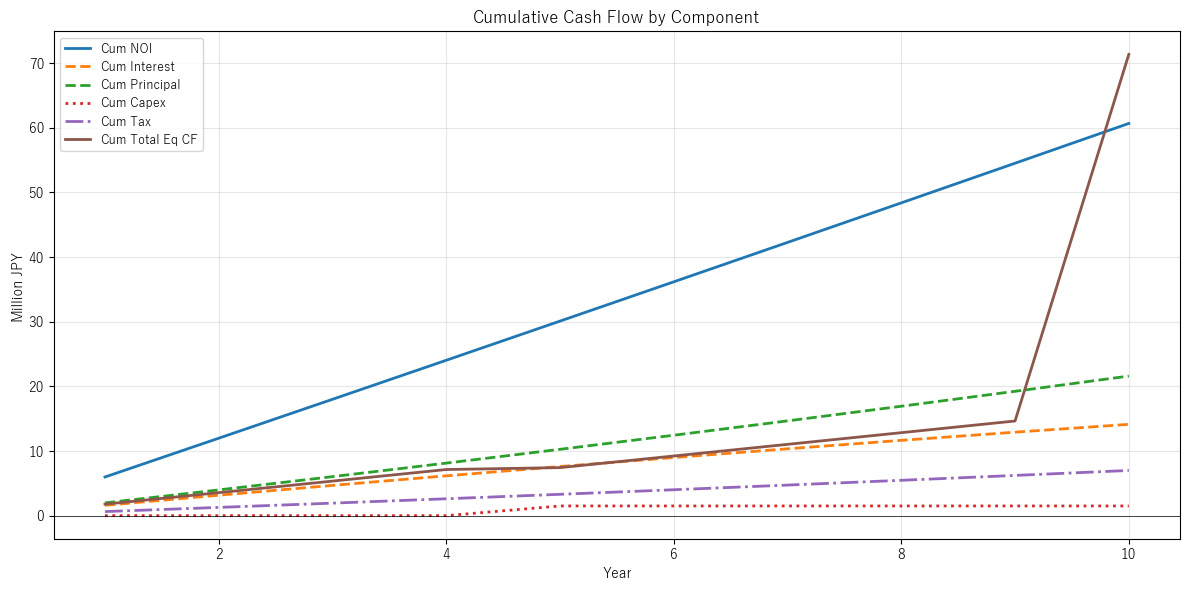

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
years = df["year"]
for col, label, ls in [
    ("cum_noi", "Cum NOI", "-"),
    ("cum_interest", "Cum Interest", "--"),
    ("cum_principal", "Cum Principal", "--"),
    ("cum_capex", "Cum Capex", ":"),
    ("cum_tax", "Cum Tax", "-."),
    ("cum_total_equity_cf", "Cum Total Eq CF", "-"),
]:
    ax.plot(years, df[col] / 1e6, label=label, linewidth=2, linestyle=ls)
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Cumulative Cash Flow by Component")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()

### Annual CF: NOI / Debt Service / BTCF / ATCF

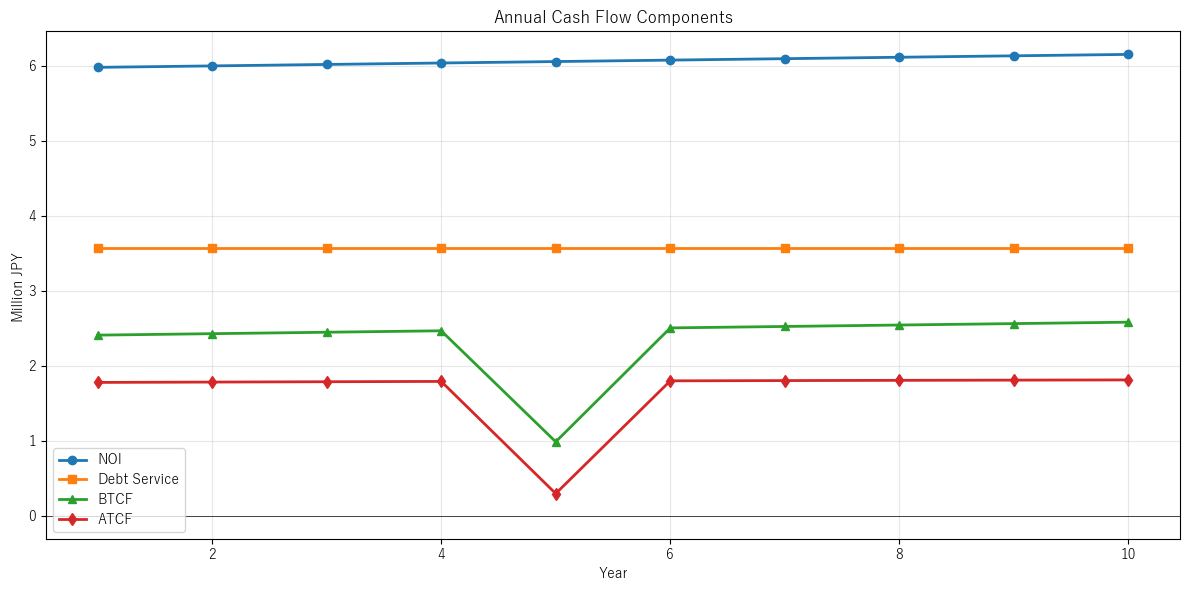

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
years = df["year"]
ax.plot(years, df["noi"]/1e6, marker="o", label="NOI", lw=2)
ax.plot(years, df["debt_service"]/1e6, marker="s", label="Debt Service", lw=2)
ax.plot(years, df["btcf"]/1e6, marker="^", label="BTCF", lw=2)
ax.plot(years, df["atcf"]/1e6, marker="d", label="ATCF", lw=2)
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Annual Cash Flow Components")
ax.legend(); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()

### B. Operating P/L 推移

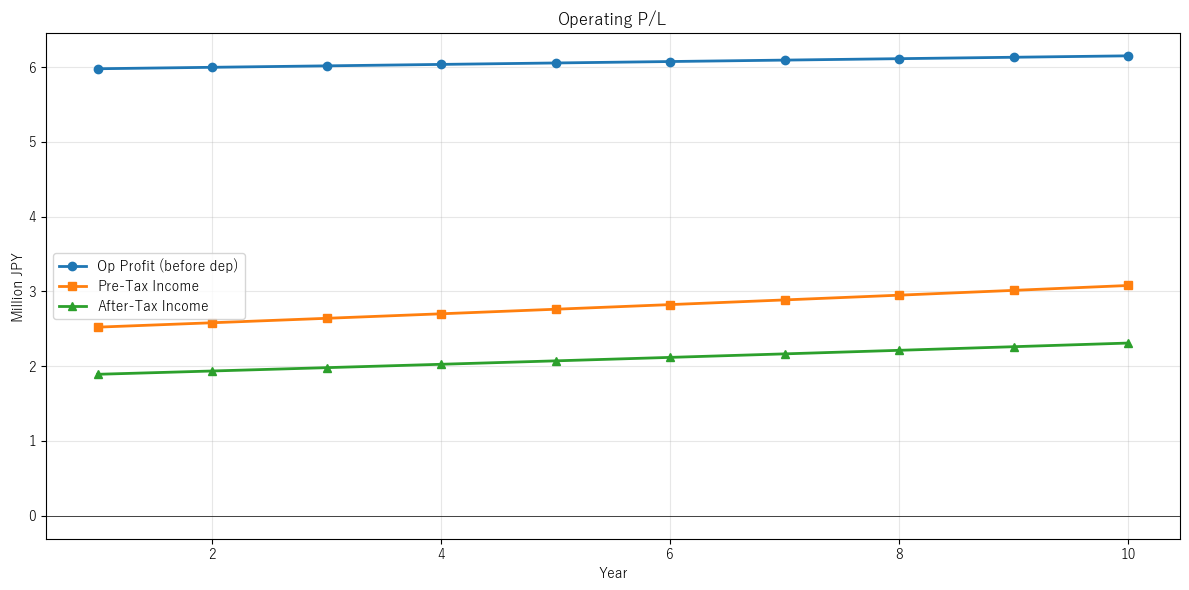

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
years = pl_df["year"]
ax.plot(years, pl_df["operating_profit_before_dep"]/1e6, marker="o", label="Op Profit (before dep)", lw=2)
ax.plot(years, pl_df["accounting_pre_tax_income"]/1e6, marker="s", label="Pre-Tax Income", lw=2)
ax.plot(years, pl_df["accounting_after_tax_income"]/1e6, marker="^", label="After-Tax Income", lw=2)
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Operating P/L")
ax.legend(); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()

### C. Market Value / Loan Balance / NAV After Tax

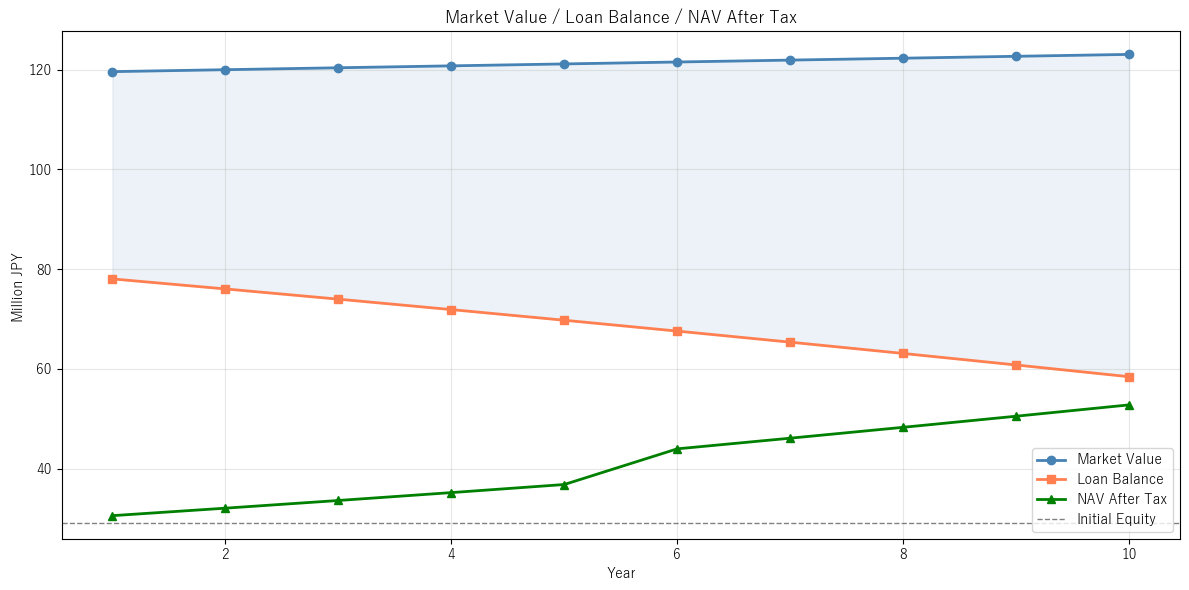

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
years = nav_df["year"]
ax.plot(years, nav_df["estimated_market_value"]/1e6, marker="o", label="Market Value", lw=2, color="steelblue")
ax.plot(years, nav_df["loan_balance_end"]/1e6, marker="s", label="Loan Balance", lw=2, color="coral")
ax.plot(years, nav_df["nav_after_tax"]/1e6, marker="^", label="NAV After Tax", lw=2, color="green")
ax.fill_between(years, nav_df["loan_balance_end"]/1e6, nav_df["estimated_market_value"]/1e6, alpha=0.1, color="steelblue")
ax.axhline(y=summary["equity_invested"]/1e6, color="gray", ls="--", lw=1, label="Initial Equity")
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Market Value / Loan Balance / NAV After Tax")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Cumulative Equity CF (Initial Equity Deducted)

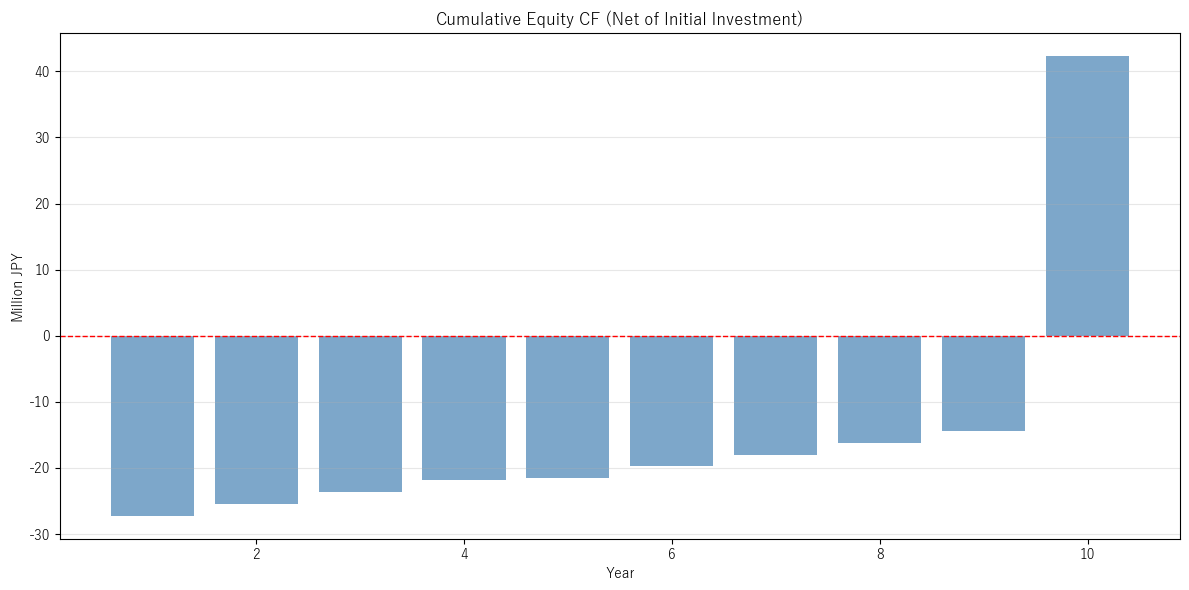

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df["year"], df["cumulative_equity_cf_with_initial"]/1e6, color="steelblue", alpha=0.7)
ax.axhline(y=0, color="red", lw=1, ls="--")
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Cumulative Equity CF (Net of Initial Investment)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

### D. Drawdown Curves (% of Peak)

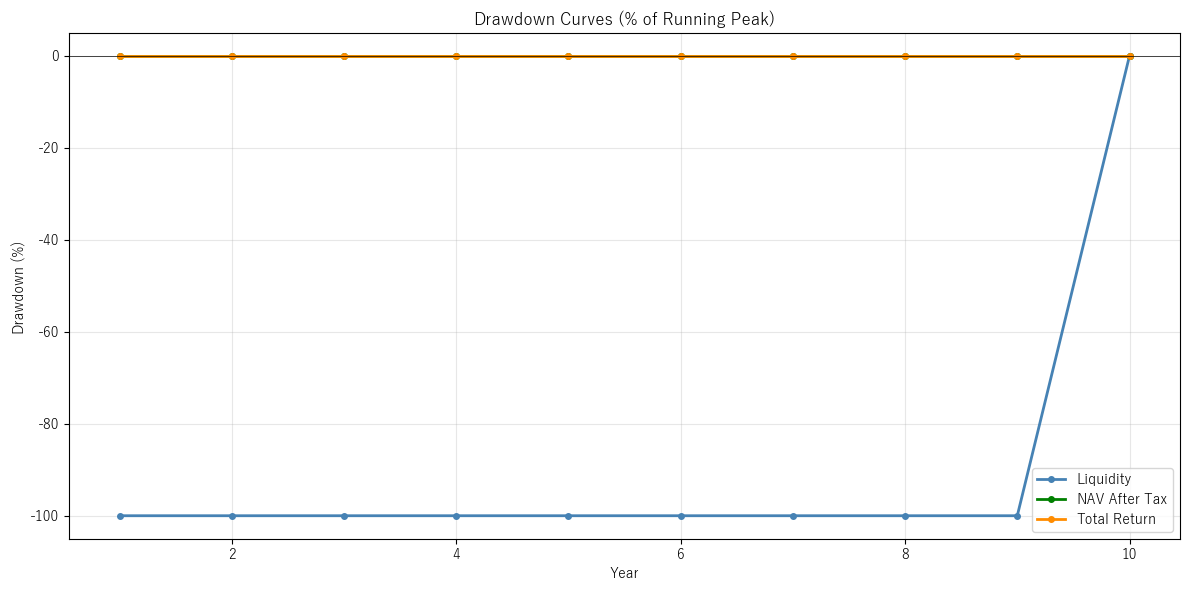

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"Liquidity": "steelblue", "NAV After Tax": "green", "Total Return": "darkorange"}
for name, data in dd_results.items():
    dd_df = data["dd_df"]
    ax.plot(dd_df["year"], dd_df["drawdown_pct"] * 100, marker="o", markersize=4,
            label=name, lw=2, color=colors.get(name, "gray"))
ax.set_xlabel("Year"); ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown Curves (% of Running Peak)")
ax.legend(); ax.grid(True, alpha=0.3); ax.axhline(y=0, color="black", lw=0.5)
plt.tight_layout(); plt.show()

### Loan Balance 推移

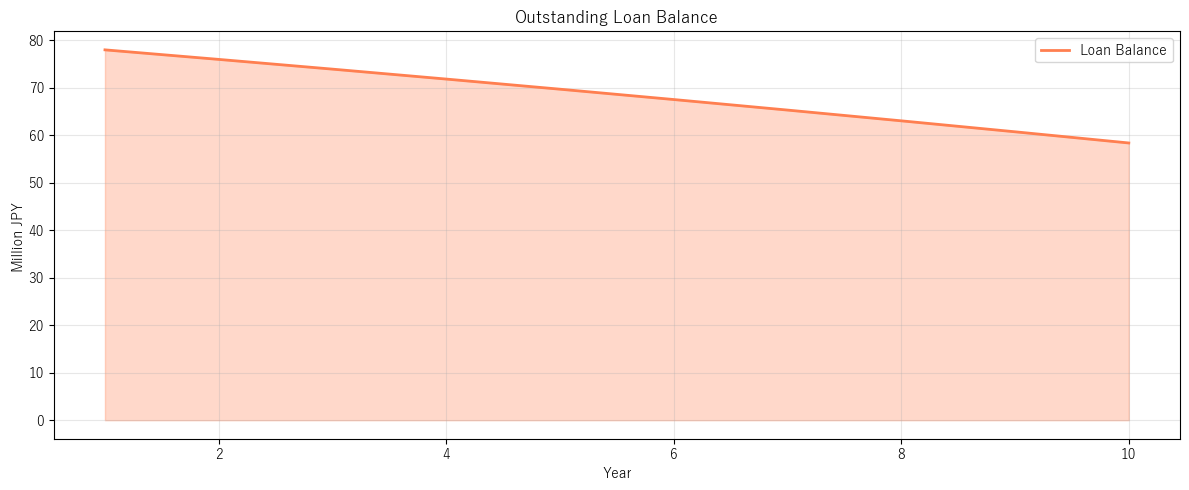

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(df["year"], df["loan_balance_end"]/1e6, alpha=0.3, color="coral")
ax.plot(df["year"], df["loan_balance_end"]/1e6, color="coral", lw=2, label="Loan Balance")
ax.set_xlabel("Year"); ax.set_ylabel("Million JPY")
ax.set_title("Outstanding Loan Balance"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## シナリオ分析

### 従来シナリオ（v1 互換）
賃料成長率・出口 Cap Rate・修繕費成長率の感応度分析。

### 拡張シナリオ（v2）
Multi-Metric 比較テーブルを生成。

=== Rent Growth Sensitivity ===
Rent Growth  Equity IRR  Eq Multiple
      -1.0%       6.87%        1.76x
       0.0%       9.71%        2.22x
       0.5%      11.00%        2.46x
       1.0%      12.22%        2.71x
       2.0%      14.48%        3.24x


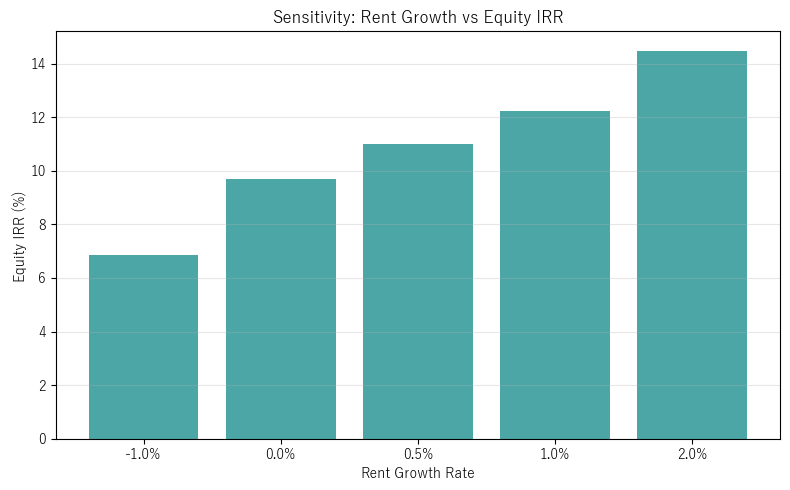

In [32]:
# --- シナリオ 1: 賃料成長率 ---
rent_growth_scenarios = [-0.01, 0.0, 0.005, 0.01, 0.02]
results_rent = []
for rg in rent_growth_scenarios:
    _, _, m, _ = run_scenario(params, {"rent_growth_rate": rg})
    results_rent.append({"Rent Growth": f"{rg:.1%}", "Equity IRR": m["equity_irr"],
                         "Eq Multiple": m["equity_multiple"]})

print("=== Rent Growth Sensitivity ===")
print(pd.DataFrame(results_rent).to_string(index=False,
    float_format=lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}x"))

fig, ax = plt.subplots(figsize=(8, 5))
irrs = [r["Equity IRR"] or 0 for r in results_rent]
ax.bar([r["Rent Growth"] for r in results_rent], [x*100 for x in irrs], color="teal", alpha=0.7)
ax.set_xlabel("Rent Growth Rate"); ax.set_ylabel("Equity IRR (%)")
ax.set_title("Sensitivity: Rent Growth vs Equity IRR")
ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

=== Exit Cap Rate Sensitivity ===
Exit Cap Equity IRR  Sale Price Net Proceeds
    3.5%     16.27% 175,795,253   95,447,633
    4.0%     14.35% 153,820,846   78,550,188
    4.5%     12.61% 136,729,641   65,407,730
    5.0%     11.00% 123,056,677   54,893,764
    5.5%      9.49% 111,869,706   46,291,428
    6.0%      8.06% 102,547,231   39,122,815


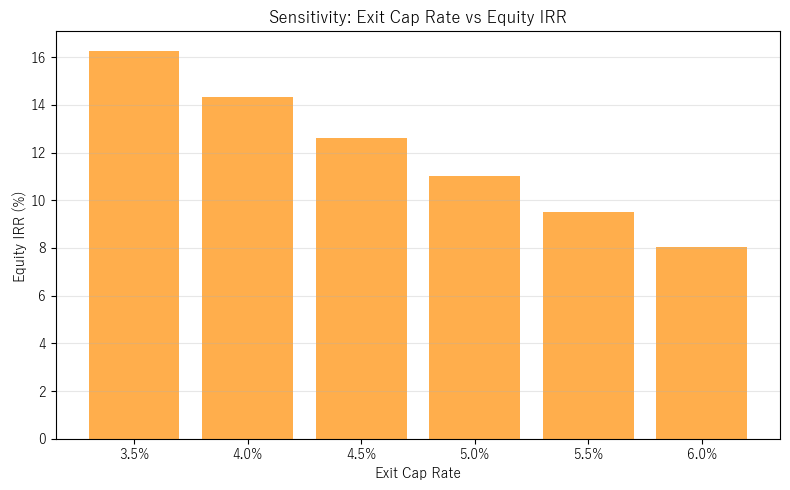

In [33]:
# --- シナリオ 2: 出口 Cap Rate ---
exit_cap_scenarios = [0.035, 0.04, 0.045, 0.05, 0.055, 0.06]
results_exit = []
for ec in exit_cap_scenarios:
    _, s, m, _ = run_scenario(params, {"exit_cap_rate": ec})
    results_exit.append({"Exit Cap": f"{ec:.1%}", "Equity IRR": m["equity_irr"],
                         "Sale Price": s["sale_price_selected"], "Net Proceeds": s["net_sale_proceeds"]})

df_exit = pd.DataFrame(results_exit)
df_ed = df_exit.copy()
df_ed["Equity IRR"] = df_ed["Equity IRR"].apply(lambda x: f"{x:.2%}" if x else "N/A")
df_ed["Sale Price"] = df_ed["Sale Price"].apply(lambda x: f"{x:,.0f}")
df_ed["Net Proceeds"] = df_ed["Net Proceeds"].apply(lambda x: f"{x:,.0f}")
print("=== Exit Cap Rate Sensitivity ===")
print(df_ed.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
irrs = [r["Equity IRR"] or 0 for r in results_exit]
ax.bar([r["Exit Cap"] for r in results_exit], [x*100 for x in irrs], color="darkorange", alpha=0.7)
ax.set_xlabel("Exit Cap Rate"); ax.set_ylabel("Equity IRR (%)")
ax.set_title("Sensitivity: Exit Cap Rate vs Equity IRR")
ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

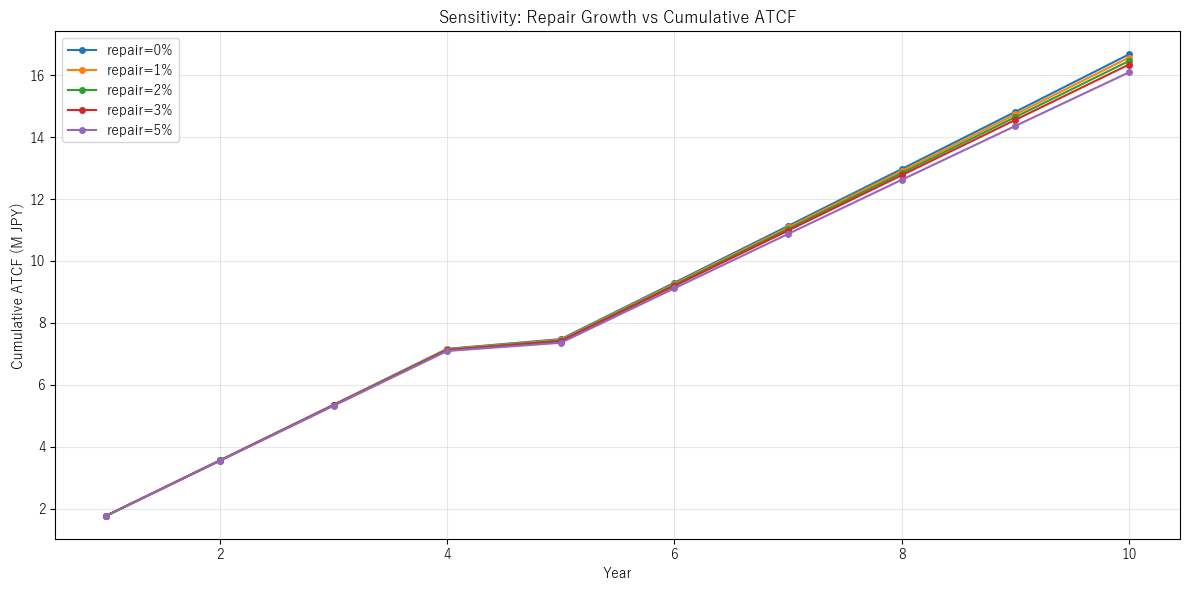

In [34]:
# --- シナリオ 3: 修繕費成長率 ---
fig, ax = plt.subplots(figsize=(12, 6))
for rg in [0.0, 0.01, 0.02, 0.03, 0.05]:
    df_s, _, _, _ = run_scenario(params, {"repair_growth_rate": rg})
    ax.plot(df_s["year"], df_s["cumulative_atcf"]/1e6, marker="o", markersize=4, label=f"repair={rg:.0%}")
ax.set_xlabel("Year"); ax.set_ylabel("Cumulative ATCF (M JPY)")
ax.set_title("Sensitivity: Repair Growth vs Cumulative ATCF")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [35]:
# --- シナリオ 4: 売却方法比較 ---
methods = ["cap_rate", "component_growth"]
comp = []
for method in methods:
    _, s, m, _ = run_scenario(params, {"exit_price_method": method})
    comp.append({"Method": method, "Sale Price": f"{s['sale_price_selected']:,.0f}",
                 "Net Proceeds": f"{s['net_sale_proceeds']:,.0f}",
                 "Equity IRR": f"{m['equity_irr']:.2%}" if m["equity_irr"] else "N/A",
                 "Eq Multiple": f"{m['equity_multiple']:.2f}x"})
print("=== Exit Method Comparison ===")
print(pd.DataFrame(comp).to_string(index=False))

=== Exit Method Comparison ===
          Method  Sale Price Net Proceeds Equity IRR Eq Multiple
        cap_rate 123,056,677   54,893,764     11.00%       2.46x
component_growth 116,603,397   49,931,448     10.15%       2.29x


### 二次元感応度テーブル（Equity IRR）

In [36]:
rent_vals = [-0.005, 0.0, 0.005, 0.01, 0.015]
exit_vals = [0.04, 0.045, 0.05, 0.055, 0.06]
matrix = {}
for rg in rent_vals:
    row = {}
    for ec in exit_vals:
        _, _, m, _ = run_scenario(params, {"rent_growth_rate": rg, "exit_cap_rate": ec})
        irr = m["equity_irr"]
        row[f"Exit {ec:.1%}"] = f"{irr:.2%}" if irr is not None else "N/A"
    matrix[f"Rent {rg:+.1%}"] = row
df_matrix = pd.DataFrame(matrix).T
df_matrix.index.name = "Rent Growth \\ Exit Cap"
print("=== Equity IRR Sensitivity Matrix ===")
df_matrix

=== Equity IRR Sensitivity Matrix ===


,Exit 4.0%,Exit 4.5%,Exit 5.0%,Exit 5.5%,Exit 6.0%
Rent Growth \ Exit Cap,,,,,
Rent -0.5%,11.96%,10.09%,8.34%,6.68%,4.81%
Rent +0.0%,13.18%,11.38%,9.71%,8.13%,6.62%
Rent +0.5%,14.35%,12.61%,11.00%,9.49%,8.06%
Rent +1.0%,15.47%,13.77%,12.22%,10.77%,9.40%
Rent +1.5%,16.54%,14.89%,13.38%,11.98%,10.67%


## 表6: Multi-Metric シナリオ比較

In [37]:
scenario_list = [
    {"label": "Base Case",           "overrides": {}},
    {"label": "Rent -1%",            "overrides": {"rent_growth_rate": -0.01}},
    {"label": "Rent +2%",            "overrides": {"rent_growth_rate": 0.02}},
    {"label": "Exit Cap 4%",         "overrides": {"exit_cap_rate": 0.04}},
    {"label": "Exit Cap 6%",         "overrides": {"exit_cap_rate": 0.06}},
    {"label": "Component Growth",    "overrides": {"exit_price_method": "component_growth"}},
    {"label": "High Repair (5%)",    "overrides": {"repair_growth_rate": 0.05}},
    {"label": "Interest 3%",         "overrides": {"interest_rate": 0.03}},
    {"label": "Hold 20Y",            "overrides": {"hold_period_years": 20}},
]

scenario_summary_df = build_extended_scenario_summary(params, scenario_list)

# Display with formatting
fmt_df = scenario_summary_df.copy()
fmt_df["Equity IRR"] = fmt_df["Equity IRR"].apply(lambda x: f"{x:.2%}" if x else "N/A")
fmt_df["Equity Multiple"] = fmt_df["Equity Multiple"].apply(lambda x: f"{x:.2f}x")
fmt_df["Avg CoC"] = fmt_df["Avg CoC"].apply(lambda x: f"{x:.2%}")
fmt_df["Min DSCR"] = fmt_df["Min DSCR"].apply(lambda x: f"{x:.2f}")
fmt_df["Min ICR"] = fmt_df["Min ICR"].apply(lambda x: f"{x:.2f}")
fmt_df["BE Year (Cash)"] = fmt_df["BE Year (Cash)"].apply(lambda x: str(int(x)) if x else "N/A")
fmt_df["Peak Neg CF (M)"] = fmt_df["Peak Neg CF (M)"].apply(lambda x: f"{x:,.1f}")
fmt_df["Final NAV AT (M)"] = fmt_df["Final NAV AT (M)"].apply(lambda x: f"{x:,.1f}")
fmt_df["Max DD% Liq"] = fmt_df["Max DD% Liq"].apply(lambda x: f"{x:.1%}")
fmt_df["Max DD% NAV"] = fmt_df["Max DD% NAV"].apply(lambda x: f"{x:.1%}")
fmt_df["Max DD% TR"] = fmt_df["Max DD% TR"].apply(lambda x: f"{x:.1%}")
fmt_df["Worst 1Y (M)"] = fmt_df["Worst 1Y (M)"].apply(lambda x: f"{x:,.1f}")
fmt_df["Worst 3Y (M)"] = fmt_df["Worst 3Y (M)"].apply(lambda x: f"{x:,.1f}")
print("=== Multi-Metric Scenario Comparison ===")
fmt_df.set_index("Scenario")

=== Multi-Metric Scenario Comparison ===


,Equity IRR,Equity Multiple,Avg CoC,Min DSCR,Min ICR,BE Year (Cash),Peak Neg CF (M),Final NAV AT (M),Max DD% Liq,Max DD% NAV,Max DD% TR,Worst 1Y (M),Worst 3Y (M)
Scenario,,,,,,,,,,,,,
Base Case,11.00%,2.46x,8.09%,1.67,3.74,10,-27.2,52.8,-100.0%,0.0%,0.0%,0.3,3.9
Rent -1%,6.87%,1.76x,6.25%,1.43,3.74,10,-27.2,36.5,-100.0%,0.0%,0.0%,-0.1,2.6
Rent +2%,14.48%,3.24x,10.07%,1.67,3.74,10,-27.2,71.1,-100.0%,0.0%,0.0%,0.7,4.7
Exit Cap 4%,14.35%,3.28x,8.09%,1.67,3.74,10,-27.2,76.4,-100.0%,0.0%,0.0%,0.3,3.9
Exit Cap 6%,8.06%,1.92x,8.09%,1.67,3.74,10,-27.2,37.0,-100.0%,0.0%,-100.0%,0.3,3.9
Component Growth,10.15%,2.29x,8.09%,1.67,3.74,10,-27.2,47.8,-100.0%,0.0%,-100.0%,0.3,3.9
High Repair (5%),10.64%,2.39x,7.92%,1.67,3.74,10,-27.2,51.1,-100.0%,0.0%,0.0%,0.3,3.8
Interest 3%,9.72%,2.27x,6.33%,1.47,2.49,10,-27.5,50.4,-100.0%,0.0%,0.0%,-0.0,2.9
Hold 20Y,9.21%,3.96x,8.67%,1.67,3.74,17,-27.2,78.2,-100.0%,0.0%,0.0%,0.3,3.9


### E. シナリオ別指標バーチャート

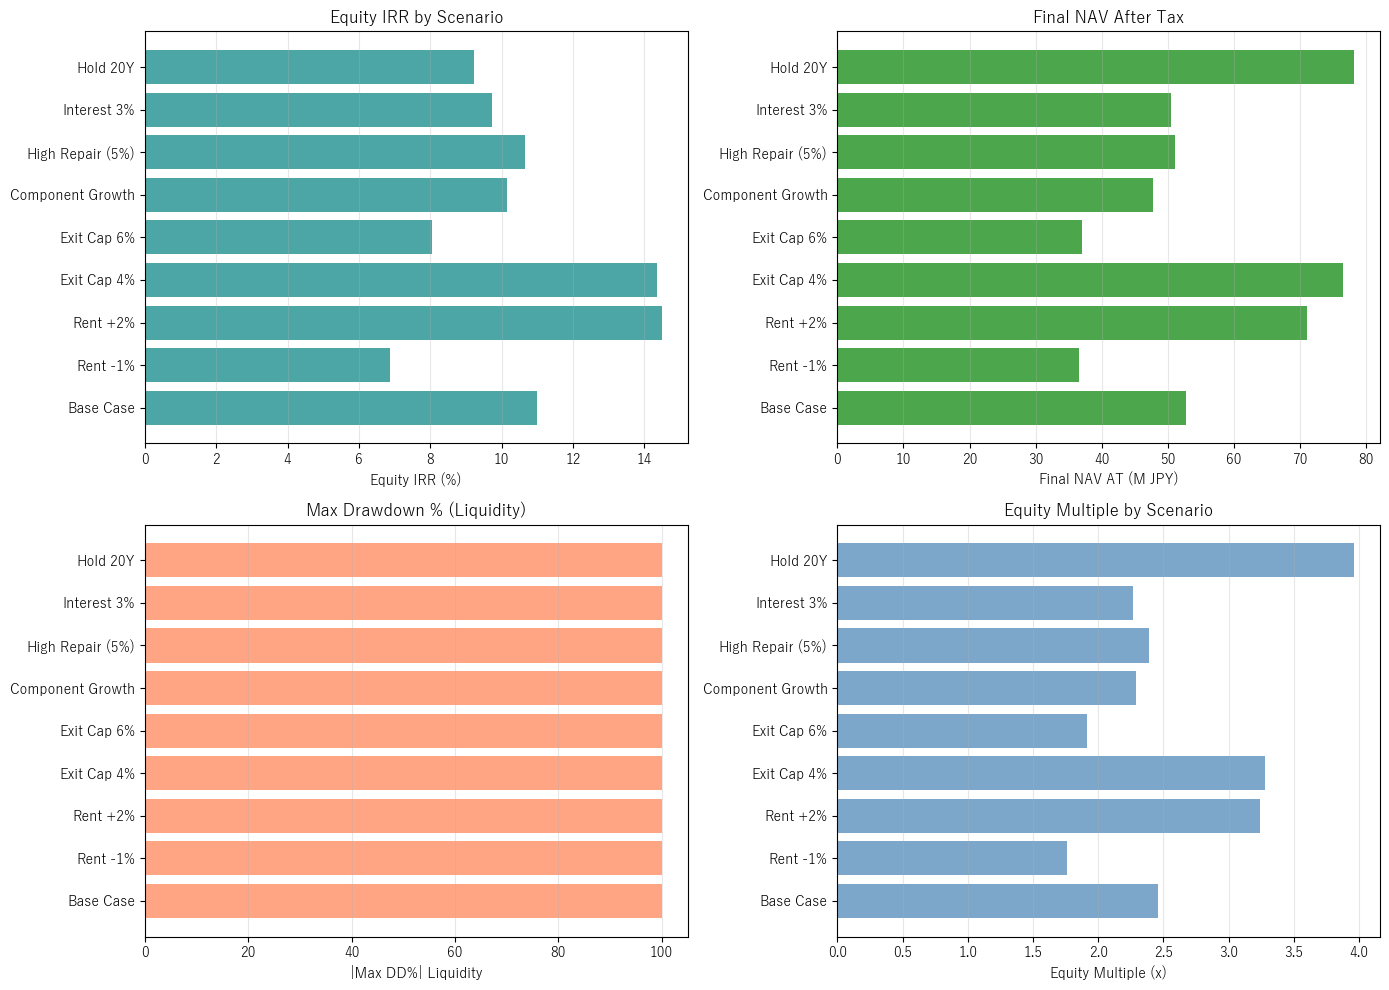

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

raw = scenario_summary_df

# Equity IRR
ax = axes[0, 0]
irr_vals = [x if x else 0 for x in raw["Equity IRR"]]
ax.barh(raw["Scenario"], [x*100 for x in irr_vals], color="teal", alpha=0.7)
ax.set_xlabel("Equity IRR (%)"); ax.set_title("Equity IRR by Scenario")
ax.grid(True, alpha=0.3, axis="x")

# Final NAV AT
ax = axes[0, 1]
ax.barh(raw["Scenario"], raw["Final NAV AT (M)"], color="green", alpha=0.7)
ax.set_xlabel("Final NAV AT (M JPY)"); ax.set_title("Final NAV After Tax")
ax.grid(True, alpha=0.3, axis="x")

# Max DD% Liquidity
ax = axes[1, 0]
ax.barh(raw["Scenario"], raw["Max DD% Liq"].abs()*100, color="coral", alpha=0.7)
ax.set_xlabel("|Max DD%| Liquidity"); ax.set_title("Max Drawdown % (Liquidity)")
ax.grid(True, alpha=0.3, axis="x")

# Equity Multiple
ax = axes[1, 1]
ax.barh(raw["Scenario"], raw["Equity Multiple"], color="steelblue", alpha=0.7)
ax.set_xlabel("Equity Multiple (x)"); ax.set_title("Equity Multiple by Scenario")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

---
## v2 で追加したこと

### 新規分析
1. **キャッシュフロー項目別累積分析** — 各 CF 項目の累積推移、Break-even Year、Peak Negative CF、Cash Recovery Ratio
2. **Operating P/L** — 会計的な損益テーブル（元本返済は含まない）。Tax Shield の算出も追加
3. **年末時価評価・NAV 分析** — Cap Rate / Component Growth 両方式での年末推定時価、Deferred Tax、NAV After Tax、Economic P/L
4. **Drawdown / Path Risk** — Liquidity / NAV / Total Return の3曲線に対する Drawdown 分析。Max DD%、Duration、Recovery Year、Worst 1Y/3Y Change
5. **Multi-Metric シナリオ比較** — 9 シナリオ × 14 指標の一覧テーブル + バーチャート

### 新規指標
- ICR (Interest Coverage Ratio)
- Break-even Year (Cash / NAV)
- Peak Negative Cumulative CF
- Final NAV After Tax
- Max Drawdown % (Liquidity / NAV / Total Return)
- Worst 1Y / 3Y Change

### 新規関数
- `add_cumulative_cashflow_columns(df, params)`
- `build_operating_pl_table(df, params)`
- `build_nav_table(df, params)`
- `compute_drawdown_series(years, values)`
- `compute_path_risk_metrics(dd_df)`
- `build_drawdown_analysis(df, nav_df, params)`
- `build_extended_scenario_summary(base_params, scenario_list)`

---
## v2 の限界

- **年次モデル**: 月次 CF をモデル化していないため、月中キャッシュフローの精度は低い
- **税務の簡易化**: 個人の累進税率は未対応。欠損繰越・損益通算なし
- **CAPEX の税務資本化**: 大規模修繕を全額費用処理。実際には資産計上 → 追加償却が正しい
- **NAV は推定値**: Cap Rate モードでの時価は「現在 NOI / exit_cap_rate」であり、forward NOI ではない
- **Drawdown**: ピークが常に負の場合は `-100%` として扱うため、解釈に注意
- **Economic P/L**: ATCF + ΔNAV の定義を採用。会計 PL や IRR とは別概念
- **単一物件**: ポートフォリオ効果は未対応

---
## v3 で追加したいこと

### 税務精緻化
- [ ] 個人の累進税率（所得税率テーブル）
- [ ] 欠損繰越（個人3年、法人10年）
- [ ] 損益通算（不動産所得の赤字 → 給与所得等と通算）
- [ ] Depreciation Recapture の精緻計算
- [ ] 消費税・登録免許税・不動産取得税の個別モデル化

### CAPEX の精緻化
- [ ] Capex の税務資本化・追加償却（付随設備の短期償却含む）
- [ ] adjusted_total_tax_basis への capex 累計反映

### モデル高度化
- [ ] **月次化**: 年次 → 月次 CF（賃料収入の季節変動・契約更新タイミング対応）
- [ ] **金利の時系列変動**: 変動金利・金利スワップのモデル化
- [ ] **空室率の動的モデル**: 築年数・エリア特性に応じた空室率変動
- [ ] **テナント構成**: 複数テナント・異なる契約条件

### 分析高度化
- [ ] **複数物件ポートフォリオ**: 物件間の CF 統合・相関・分散効果
- [ ] **Monte Carlo シミュレーション**: 賃料・空室率・金利・Cap Rate 等の確率変動
- [ ] **感応度ヒートマップ**: 2 変数 × 複数指標の可視化
- [ ] **売却タイミング最適化**: 各年の売却 IRR/NAV を比較して最適解を探索

### UX / 技術
- [ ] **Streamlit / Gradio**: インタラクティブダッシュボード
- [ ] **クラス設計**: Property / Loan / TaxCalculator のオブジェクト化
- [ ] **YAML/JSON 設定ファイル**: パラメータの外部管理
- [ ] **PDF レポート自動生成**: テーブル・チャートをワンクリックで出力